# P03. Rheology and Io

A body's tidal response depends on how its material deforms under a periodic load, which is set by its rheology. A rheology combines an elastic shear modulus and a viscosity into a frequency-dependent complex shear modulus. The radial solver turns that into a complex Love number $k_2$. The imaginary part sets the dissipation, so the tidal heating is $-\mathrm{Im}(k_2)$ times orbital factors.

Dissipation peaks at an intermediate viscosity. For a body whose shear modulus is well above its gravitational stiffness $\rho g R$ (about $10^{10}$ Pa for Io), the heating of a Maxwell body peaks near $\eta \approx 2 \rho g R / (19\,\omega)$, about $3 \times 10^{13}$ Pa s for Io, whatever the shear modulus. Only in a much softer body does the peak sit where the Maxwell time (viscosity over shear modulus) matches the tidal period. This notebook maps Io's tidal heating across shear modulus and viscosity for four rheologies, and compares the four rheologies' attenuation across forcing frequency.

Io is modeled as a uniform, incompressible sphere, solved with the propagation matrix. For this body the solver reproduces the closed form $k_2 = (3/2) / (1 + 19 \tilde{\mu} / (2 \rho g R))$ (Love 1911) across the whole map, as the map cell checks. A uniform compressible sphere is unstably stratified where its shear modulus is far below $\rho g R$, so its solve is unreliable there (see `Benchmarks/RadialSolver/Homogeneous_Viscoelastic_Love_Numbers.ipynb`).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G, M_jup
from TidalPy.RadialSolver import homogeneous_love_numbers
from TidalPy.Rheology import Maxwell, Burgers, Andrade, Sundberg

# Io as a homogeneous sphere, tidally forced by Jupiter.
R = 1.8216e6
M = 8.9319e22
RHO = M / (4.0 / 3.0 * np.pi * R**3)
A_IO = 4.217e8
E_IO = 0.0041
N_MOTION = np.sqrt(G * M_jup / A_IO**3)


def love_k2(shear, viscosity, rheology):
    "Complex tidal k2 of a uniform incompressible Io with the given shear modulus, viscosity, and rheology."
    complex_shear = rheology.calc_complex_modulus(shear, viscosity, N_MOTION)
    solution = homogeneous_love_numbers(
        R,
        RHO,
        complex_shear,
        N_MOTION,
        layer_is_incompressible=True,
        love_method="propagation_matrix")
    return solution.k


# Tidal heating of a synchronous Io per unit -Im(k2), from the leading e^2 term (21/2) G M_host^2 R^5 e^2 n / a^6 [W]
HEATING_PER_NEG_IM_K2 = 10.5 * G * M_jup**2 * R**5 * E_IO**2 * N_MOTION / A_IO**6


# Each rheology is a model object; its parameters are set by keyword (these are the defaults).
rheologies = [
    ("Maxwell", Maxwell()),
    ("Burgers", Burgers(voigt_modulus_frac=5.0, voigt_viscosity_frac=0.02)),
    ("Andrade", Andrade(alpha=0.3, zeta=1.0)),
    ("Sundberg-Cooper", Sundberg(alpha=0.3, zeta=1.0, voigt_modulus_frac=5.0, voigt_viscosity_frac=0.02)),
]

# A fiducial mantle state
FIDUCIAL_SHEAR = 60.0e9  # [Pa]
FIDUCIAL_VISCOSITY = 1.0e14  # [Pa s]
for name, rheology in rheologies:
    k2 = love_k2(FIDUCIAL_SHEAR, FIDUCIAL_VISCOSITY, rheology)
    print(f"{name:16} k2 = {k2:.4f}   heating = {-k2.imag * HEATING_PER_NEG_IM_K2:.3e} W")

Maxwell          k2 = 0.1437-0.3931j   heating = 2.446e+15 W
Burgers          k2 = 0.1482-0.3902j   heating = 2.428e+15 W
Andrade          k2 = 0.1955-0.3879j   heating = 2.413e+15 W
Sundberg-Cooper  k2 = 0.1997-0.3852j   heating = 2.396e+15 W


Swapping rheologies means passing a different model object: each call builds a temporary uniform sphere from the complex shear modulus it is given. Burgers and Sundberg-Cooper add a Voigt element in series, whose modulus and viscosity are set as fractions of the main element's (`voigt_modulus_frac`, `voigt_viscosity_frac`); Andrade and Sundberg-Cooper add transient creep set by `alpha` and `zeta`. The fiducial state sits near the dissipation peak, so it gives about 24 times Io's observed heat output of about $10^{14}$ W, and there the four rheologies agree within 2 percent (the last section explains why).

## Heating Across Shear Modulus and Viscosity

Each panel maps the tidal heating across mantle shear modulus and viscosity for one rheology, on one shared color scale. Above a shear modulus of about $10^{10}$ Pa the ridge of strongest heating runs at a nearly constant viscosity of $10^{13}$ to $10^{14}$ Pa s. The Voigt element of Burgers and Sundberg-Cooper adds a second, much weaker ridge at higher viscosity, where that element relaxes at the forcing period. The transient creep of Andrade and Sundberg-Cooper keeps the heating high far toward higher viscosity, so these two rheologies dissipate over a much wider range of conditions than a Maxwell body.

Maxwell          largest relative difference from the closed form: 8.1e-10


Burgers          largest relative difference from the closed form: 8.7e-10


Andrade          largest relative difference from the closed form: 1.7e-09


Sundberg-Cooper  largest relative difference from the closed form: 1.8e-09


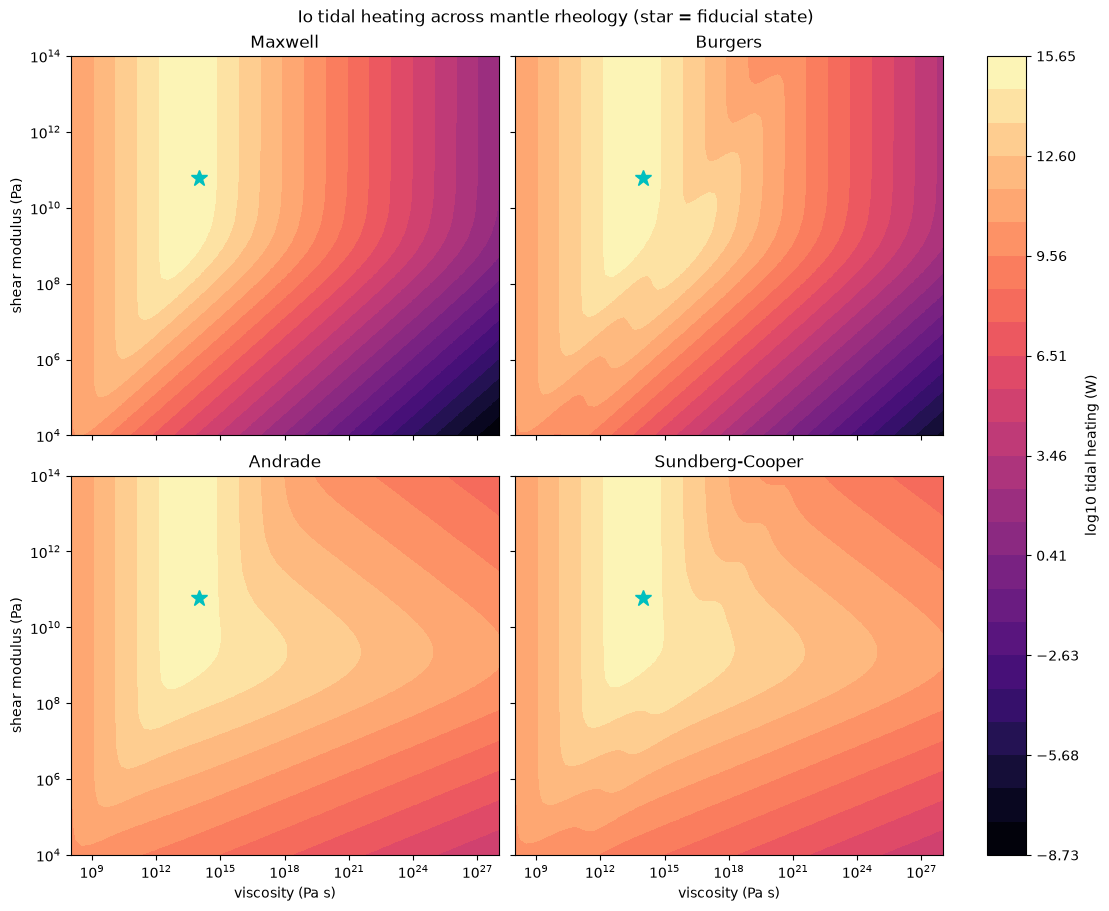

In [2]:
shear_axis = np.logspace(4, 14, 75)
viscosity_axis = np.logspace(8, 28, 76)
shear_grid, viscosity_grid = np.meshgrid(shear_axis, viscosity_axis)
rho_g_r = RHO * (G * M / R**2) * R  # gravitational stiffness [Pa]

log_heating = {}
for name, rheology in rheologies:
    neg_im_k2 = np.array([[-love_k2(mu, eta, rheology).imag for mu in shear_axis] for eta in viscosity_axis])
    log_heating[name] = np.log10(neg_im_k2 * HEATING_PER_NEG_IM_K2)

    # Check the solver against the closed form for a uniform incompressible sphere (Love 1911)
    complex_shear_grid = rheology.calc_complex_modulus(shear_grid, viscosity_grid, N_MOTION)
    closed_form = 1.5 / (1.0 + 19.0 * complex_shear_grid / (2.0 * rho_g_r))
    largest_error = np.max(np.abs(neg_im_k2 / -closed_form.imag - 1.0))
    print(f"{name:16} largest relative difference from the closed form: {largest_error:.1e}")

# One color scale for every panel
levels = np.linspace(min(grid.min() for grid in log_heating.values()),
                     max(grid.max() for grid in log_heating.values()), 25)

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True, layout="constrained")
for ax, (name, rheology) in zip(axes.ravel(), rheologies):
    contours = ax.contourf(viscosity_grid, shear_grid, log_heating[name], levels=levels, cmap="magma")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(name)
    ax.plot(FIDUCIAL_VISCOSITY, FIDUCIAL_SHEAR, "c*", ms=12)
for ax in axes[-1]:
    ax.set_xlabel("viscosity (Pa s)")
for ax in axes[:, 0]:
    ax.set_ylabel("shear modulus (Pa)")
fig.colorbar(contours, ax=axes, label="log10 tidal heating (W)")
fig.suptitle("Io tidal heating across mantle rheology (star = fiducial state)")
plt.show()

## Attenuation Across Frequency

A rheology's own dissipation is its attenuation, $Q^{-1} = \mathrm{Im}(\tilde{\mu}) / \mathrm{Re}(\tilde{\mu})$: the energy a cycle loses over $2 \pi$ times the energy it stores. The plot shows it against forcing frequency at the fiducial mantle state, whose Maxwell frequency, shear modulus over viscosity, is $6 \times 10^{-4}$ rad/s.

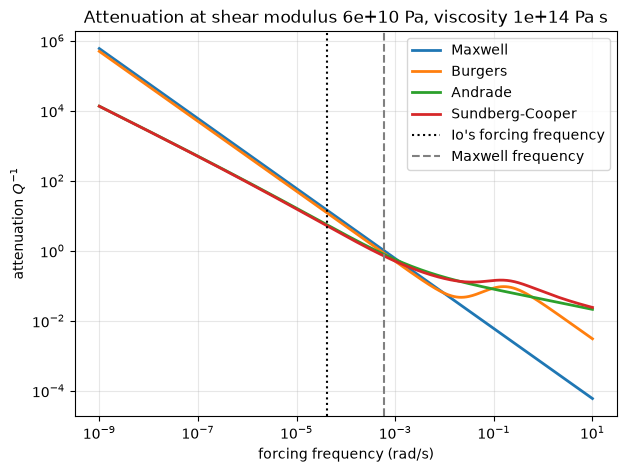

In [3]:
frequencies = np.logspace(-9.0, 1.0, 400)  # [rad s-1]

fig, ax = plt.subplots(figsize=(7, 5))
for name, rheology in rheologies:
    complex_shear = rheology.calc_complex_modulus(FIDUCIAL_SHEAR, FIDUCIAL_VISCOSITY, frequencies)
    ax.loglog(frequencies, complex_shear.imag / complex_shear.real, lw=2, label=name)
ax.axvline(N_MOTION, color="k", ls=":", label="Io's forcing frequency")
ax.axvline(FIDUCIAL_SHEAR / FIDUCIAL_VISCOSITY, color="gray", ls="--", label="Maxwell frequency")
ax.set_xlabel("forcing frequency (rad/s)")
ax.set_ylabel("attenuation $Q^{-1}$")
ax.set_title(f"Attenuation at shear modulus {FIDUCIAL_SHEAR:.0e} Pa, viscosity {FIDUCIAL_VISCOSITY:.0e} Pa s")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Above the Maxwell frequency, a Maxwell body's attenuation falls as $\omega^{-1}$, while the transient creep of Andrade and Sundberg-Cooper makes it fall only about as $\omega^{-\alpha}$. The Voigt element of Burgers and Sundberg-Cooper adds a second peak near its own relaxation frequency, $\mu_V / \eta_V$ = 0.15 rad/s here (5 times the shear modulus over 0.02 times the viscosity). Below the Maxwell frequency, the transient creep also adds to the stored (real) part of the response, so Andrade and Sundberg-Cooper attenuate less than Maxwell there.

Io's forcing frequency lies below the Maxwell frequency, where the Maxwell and Andrade attenuations differ by a factor of about 3, yet the fiducial heatings above differ by 2 percent. The heating follows the whole body's $-\mathrm{Im}(k_2)$, not the material's $Q^{-1}$. At this state the body's response is set mostly by the viscous part of the modulus, $\mathrm{Im}(\tilde{\mu}) \approx \omega \eta \approx 4 \times 10^9$ Pa, which the four rheologies share within 10 percent, while $Q^{-1}$ divides it by the small elastic part $\mathrm{Re}(\tilde{\mu})$, which the transient creep more than doubles.